In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# If you like interactive plots uncomment the relevant magic command below
# %matplotlib notebook

# %matplotlib ipympl


%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
%load_ext autoreload
%autoreload 2
import pickle
from scipy.optimize import curve_fit, minimize

codepath = "/Users/jasonwu/Programs/Research/gal_fesc"
import sys, os
sys.path.append(os.path.abspath(codepath))
from codes.plotting import plot_prettier
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(f'{codepath}/codes/def.mplstyle')
pi = np.pi
plot_prettier(usetex=True)

# Introduction to scikit-learn

##### Version 0.1.1

***
By AA Miller (Northwestern/CIERA/SkAI)

08 June 2026

Broadly speaking, machine-learning methods constitute a diverse collection of data-driven algorithms designed to classify/characterize/analyze sources in multi-dimensional spaces. The topics and studies that fall under the umbrella of machine learning is growing, and there is no good catch-all definition. We cannot cover all possible algorithms.

Today we will focus on the [`scikit-learn`](https://scikit-learn.org/stable/index.html) python library, which provides a nice interface to build a wide variety of machine learning models. As we will see, `scikit-learn` makes machine learning "easy."

## Problem 1) Data with `scikit-learn`

In 4 lines we can build a non-linear classifier for the famous [iris data set](https://en.wikipedia.org/wiki/Iris_flower_data_set).

    from sklearn import datasets
    from sklearn.ensemble import RandomForestClassifier
    iris = datasets.load_iris()
    RFclf = RandomForestClassifier().fit(iris.data, iris.target)

Those 4 lines of code have constructed a model that is superior to any system of hard cuts that we could have encoded while looking at the multidimensional space. 

It's also fast – execute the next cell.

In [3]:
# execute example code here

from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
iris = datasets.load_iris()
RFclf = RandomForestClassifier().fit(iris.data, iris.target)

Generally speaking, the procedure for `scikit-learn` is uniform across all machine-learning algorithms. Models are accessed via the various modules (`ensemble`, `SVM`, `neighbors`, etc), with user-defined tuning parameters. The features (or data) for the models are stored in a 2D array, `X`, with rows representing individual sources and columns representing the corresponding feature values.$^\dagger$  In cases where there is a known classification or scalar value (typically supervised methods), this information is stored in a 1D array `y`. 

$^\dagger$In a minority of cases, `X`, represents a similarity or distance matrix where each entry represents the distance to every other source in the data set.

Unsupervised models are fit by calling `.fit(X)` and supervised models are fit by calling `.fit(X, y)`. In both cases, predictions for new observations, `Xnew`, can be obtained by calling `.predict(Xnew)`. Those are the basics and beyond that, the details are algorithm specific, so ...

read the docs!

**Problem 1a** What is the pythonic type of `iris`?

In [4]:
# complete

type(iris)

sklearn.utils._bunch.Bunch

You likely haven't encountered a `scikit-learn Bunch` before. It's essentially the same as a dictionary. 

**Problem 1b** What are the keys of iris?

In [5]:
# complete

iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Most importantly, iris contains `data` and `target` values. These are all you need for `scikit-learn`, though the feature and target names and description are useful.

**Problem 1c** What is the shape and content of the `iris` data?

In [13]:
print(np.shape(iris.data))
# print(iris.data)

# complete

(150, 4)


The data is a 2d array with shape 150 x 4.

We said earlier that each row represents a source and each column a "feature."

**Problem 1d**

What is the first feature in the `iris` data set? What units is it measured in?

In [23]:
# complete

iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

sepal length and cm

**Problem 1e** 

What is the shape and content of the `iris` target?

In [25]:
print(np.shape(iris.target))
print(np.unique(iris.target))
# complete

(150,)
[0 1 2]


**Problem 1f**

What are the names of class 0, 1, and 2 in the `iris` target?

In [26]:
# complete

iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

An important lesson from this week - **worry about the data**!

If you are worried about the data, then you should look at the data. This is actually an important aspect of applying machine learning models.

**Problem 1g** 

Make a scatter plot showing sepal length vs. sepal width for the iris data set. Color the points according to their respective classes.

*Hint* – just execute the cell below.

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


/var/folders/j0/rqdpnvss1tlbffxb8bfzwnkw0000gn/T/ipykernel_70262/1476356592.py:4: UserWarning: You passed a edgecolor/edgecolors ('None') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(iris.data[:,0], iris.data[:,1],


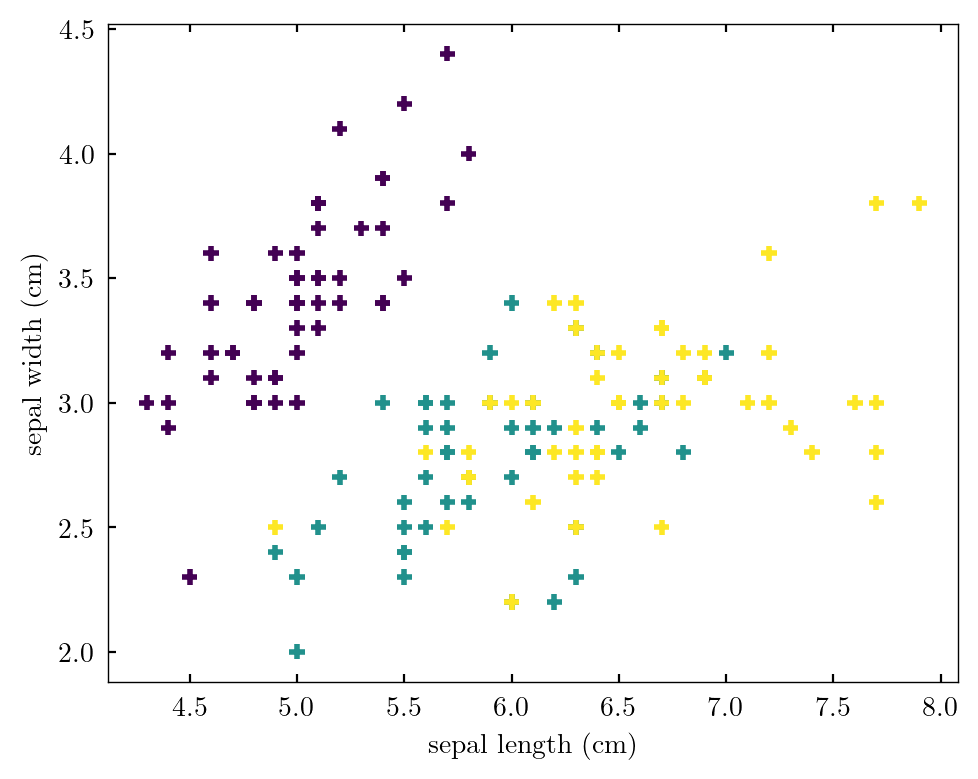

In [31]:
print(iris.feature_names)  # shows that sepal length is first feature and sepal width is second feature

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(iris.data[:,0], iris.data[:,1], 
           c = iris.target, s = 30, 
           edgecolor = "None", cmap = "viridis")
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')
fig.tight_layout()
plt.show()

We will return to the `iris` data set later in this notebook.

## Problem 2) Linear Regression

At its core, `scitkit-learn` is designed to help you, the user, easily fit models to data. 

To demonstrate this we will start with a familiar example - linear regression. 

**Problem 2a**

Simulate data drawn from a linear relationship with Gaussian scatter. 

In [32]:
np.random.seed(2012)
n_obs = 25
x = np.random.uniform(0,100, n_obs)
y_true = 2.3*x + 14
y_obs = y_true + np.random.normal(0, 15, n_obs)

**Problem 2b**

Plot the simulated data. Overplot the true relation from which the data are drawn. 

*Hint* – just execute the cell below.

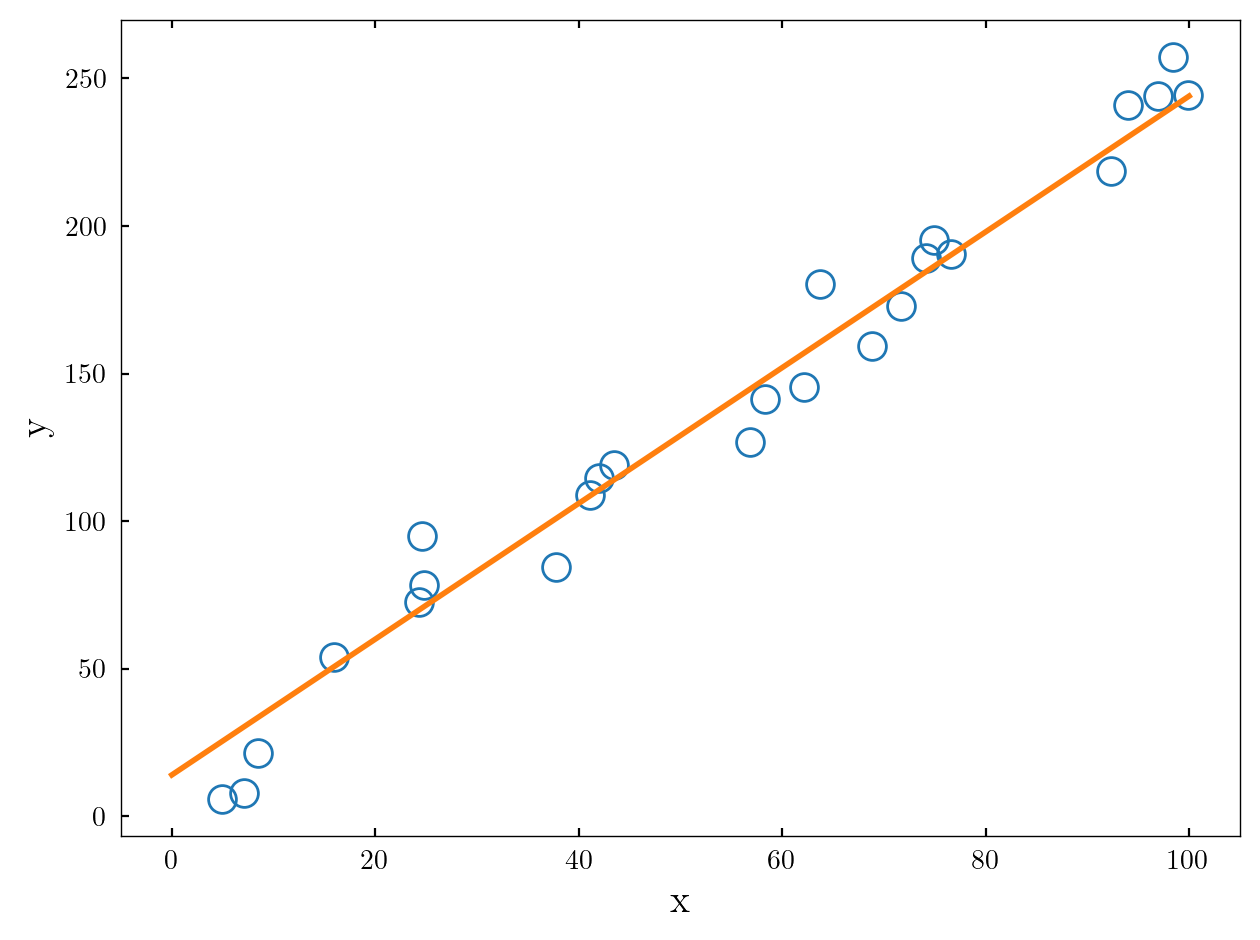

In [33]:
fig, ax = plt.subplots()
ax.plot(x, y_obs, 'o', mfc="None")
ax.plot([0,100], [14, 244])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
fig.tight_layout()
plt.show()

The [`sklearn.linear_model`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model) has a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) class.

The "standard" procedure in `scikit-learn` is to generate the model by creating an instance of the relevant class object (e.g., `reg_model = LinearRegression()`). 

The model is then trained using the aforementioned training and label arrays, `X` and `y`, with the `.fit()` method. 

Finally, predictions can be made using the `.predict()` method (note - the precise syntax for this can vary depending on the model being used). 

**Problem 2c** 

Generate an instance of the `LinearRegression` class. Call this instance `reg_model`.

In [34]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()  # complete

**Problem 2d** 

Fit the model to the training data `x` and `y_obs`. 

*Hint* - the standard feature array in `scikit-learn` is 2D, so you will need to convert `x` to a 2D array.

In [50]:
X = x.reshape([len(x), 1])  # complete
reg_model.fit(X, y_obs) # complete

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Problem 2e**

Output the best-fit parameters from the model (these are stored in the `.coef_` and `.intercept_` attributes). 

Overplot the best-fit line on top of the observations.

The best fit is y = 2.4260015592346775 * x + 6.373264215931641


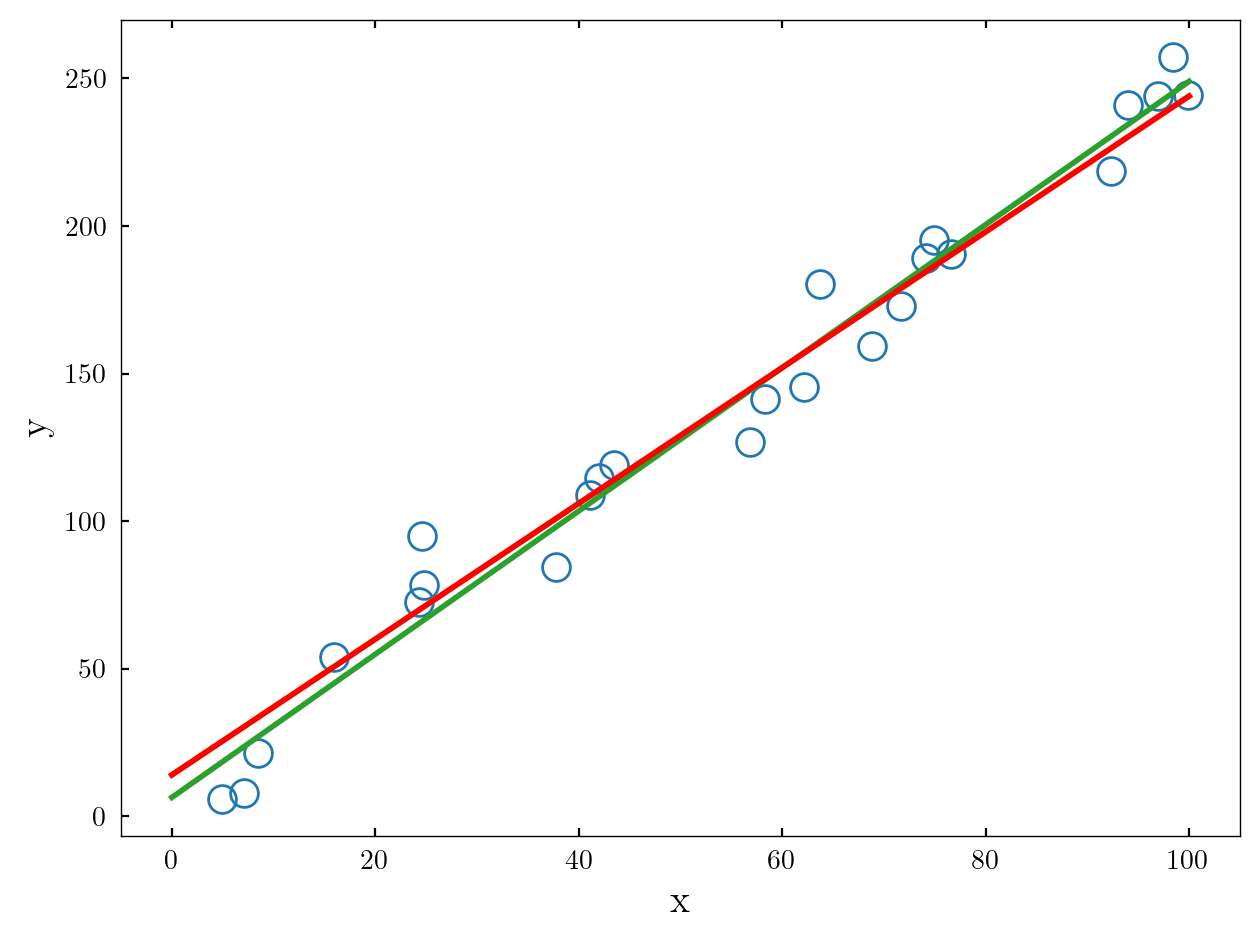

In [63]:
print(f'The best fit is y = {reg_model.coef_[0]} * x + {reg_model.intercept_}') # complete

fig, ax = plt.subplots()
ax.plot(x, y_obs, 'o', mfc="None")
ax.plot([0,100], [14, 244])
ax.plot([0,100], [reg_model.intercept_, 100*reg_model.coef_[0] + reg_model.intercept_])

# or numpy
ax.plot([0,100], np.polyval(np.polyfit([0,100], [14, 244], 1), [0,100]), color='red')


ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
fig.tight_layout()
plt.show()

**Problem 2f**

Fit for the model parameters using some other method (e.g., `numpy`, `scipy`, linear algebra), and compare the model parameters to those found with `scikit-learn`.

In [64]:
# complete

print(f'The best fit is y = {reg_model.coef_[0]} * x + {reg_model.intercept_}') # complete

The best fit is y = 2.4260015592346775 * x + 6.373264215931641


In [65]:
np.polyfit([0,100], [14, 244], 1)

array([ 2.3, 14. ])

The results are identical!

Under the hood, polynomial regression is just linear algebra, so it doesn't matter which library you use to solve the problem. Both `numpy` and `scikit-learn` can handle multi-dimensional input and even account for uncertainties on the observations via input weights. For this problem, it does not matter which library you use. 

## Problem 3) Linear Classification

We will now examine why linear regression does not work for classification. 

Suppose we have a method to measure the mass of a galaxy (but this method has noise). We would like to separate the galaxies into two classes "normal" and "dwarf", where dwarf galaxies are those with a mass below 60. We could simulate such a dataset as follows.

*Note* - this is very much a "toy" data set to be used purely for illustration. While we use some familiar terms, nothing about this is truly physical, which is why we do not include units, etc.

In [66]:
np.random.seed(2024)
n_obs = 200
mass = np.random.normal(65, 20, size=n_obs)
mass[mass > 70] *= (mass[mass > 70]-60)/60*5
y = (mass > 60).astype(bool)
obs_mass = mass + np.random.normal(0, 7, size=n_obs)
X = obs_mass.reshape(-1,1)

In the previous cell we have simulated 200 galaxies, most of which are normal with masses > 60. We use this information to define our class vector `y`, such that all normal galaxies have a class of 1 and all dwarf galaxies have a class of 0. Finally, we simulate our observations `X`, which adds Gaussian noise to the true mass measurements. 

**Problem 3a**

Build a classifier using `LinearRegression()`. Find the best fit line for the data. All sources with an extrapolated best-fit value > 0.5 are classified as normal, and everything else is considered a dwarf. 

From the training data, how accurate is this model?

In [73]:
# y is the true y
# obs_mass is the data y

In [90]:
reg_model = LinearRegression()  # complete
reg_model.fit(X, y.astype(float)) # complete

y_pred = reg_model.predict(X) # complete
y_pred = np.array([y > 0.5 for y in y_pred]).astype(float)

n_incorrect = np.sum((y_pred - y)**2)

accuracy = (n_obs - n_incorrect)/n_obs

print(f'This model has an accuracy of {accuracy:.3f}')

This model has an accuracy of 0.890


**Problem 3b**

To understand the short-comings of this model, plot the data. Overplot the best-fit linear regression model. 

In [97]:
np.min(X), np.max(X)

(4.195221080076783, 580.3342150782979)

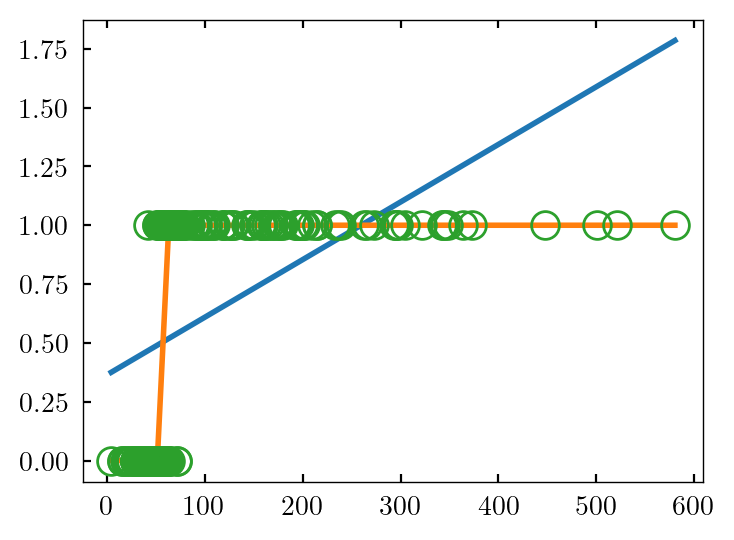

In [101]:
fig, ax = plt.subplots(figsize=(4, 3))
xlin = np.linspace(np.min(X), np.max(X))


# line
ylin = reg_model.predict(xlin.reshape([len(xlin), 1]))
ax.plot(xlin, ylin)
ax.plot(xlin, np.array([y > 0.5 for y in ylin]).astype(float))


# data
ax.plot(X, y, 'o', mfc="None")

plt.show()

# complete
# complete
# complete
# complete
# complete

As we can see in the above plot, every galaxy with $\mathrm{mass} \gtrsim 78$ is classified as normal. 

It is also clear from the plot that linear regression is not a particularly good approach to this problem.

**Problem 3c**

Build a classifier via "hard cut" and assess it's accuracy. 

Find the maximum mass for dwarf galaxies in the data set. Classify all sources with a mass less than this as dwarf galaxies.

In [104]:
mass_cut = 78   # complete

y_pred = np.array([X > mass_cut]).astype(float).flatten()    # complete
# complete
n_incorrect = np.sum((y_pred - y)**2)

accuracy = (n_obs - n_incorrect)/n_obs

print(f'This model has an accuracy of {accuracy:.3f}')



# complete

This model has an accuracy of 0.745


This represents a slight improvement over the linear regression model. (Note - if you did the reverse and used the normal galaxies to determine the mass cut, you would get similar results)

At this point you must be thinking - "There has to be a better way!"

Fortunately, there is. 

[Logistic Regression](https://en.wikipedia.org/wiki/Logistic_regression) - the "hello, world" of machine learning classification.

(and also one of the absolutely worst named algorithms ever, as logistic regression is used for *classification* and not *regression*)

Briefly, logistic regression is used to understand the relationship between a dependent variable (normal vs. dwarf) and one or more independent variables (mass, but could also be mass, star formation rate, metallicity, and so on) by estimating probabilities via the logistic function.

The logistic function: 

$$ p(x) = \frac{1}{1 + e^{-(x - \mu)/s}}$$

can be rewritten as: 

$$ p(x) = \frac{1}{1 + e^{-(B_0 + B_1 x)}}$$

which recasts the problem as having a slope and intercept, similar to the linear regression problem that we worked on previously. 

**Problem 3d**

Execute the cell below to see the logistic function. 

How might this be useful for our galaxy classification problem? 

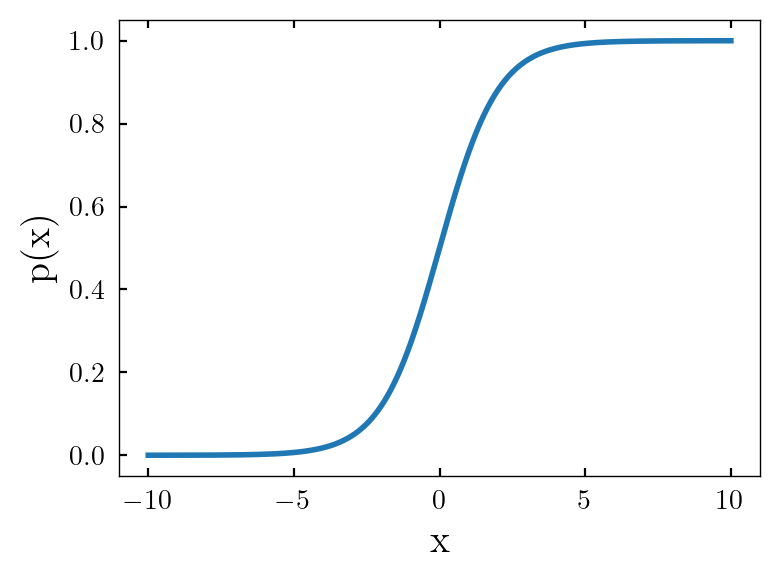

In [109]:
x = np.linspace(-10,10,1000)
p_x = 1/(1 + np.exp(-x))
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, p_x)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('p(x)', fontsize=14)
fig.tight_layout()
plt.show()

*write your answer here*

**Problem 3e**

Create an instance of the [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) class from the `sklearn.linear_model` module. 

Fit the model to the simulated galaxy data.

In [119]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()  # complete
logreg.fit(X, y.astype(float)) # complete

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Problem 3f**

Assess the accuracy of the Logistic Regression model. 

In [123]:
# complete


y_pred = logreg.predict(X.reshape([len(X), 1]))
n_incorrect = np.sum((y_pred - y)**2)

accuracy = (n_obs - n_incorrect)/n_obs

print(f'This model has an accuracy of {accuracy:.3f}')

This model has an accuracy of 0.895


This model shows significant improvement over our alternative methods! 

**Problem 3g**

Overplot the best fit logistic regression model on the data. 

*Hint* – the `.intercept_` and `.coef_` attributes can be used to determine the argument for the logistic function.

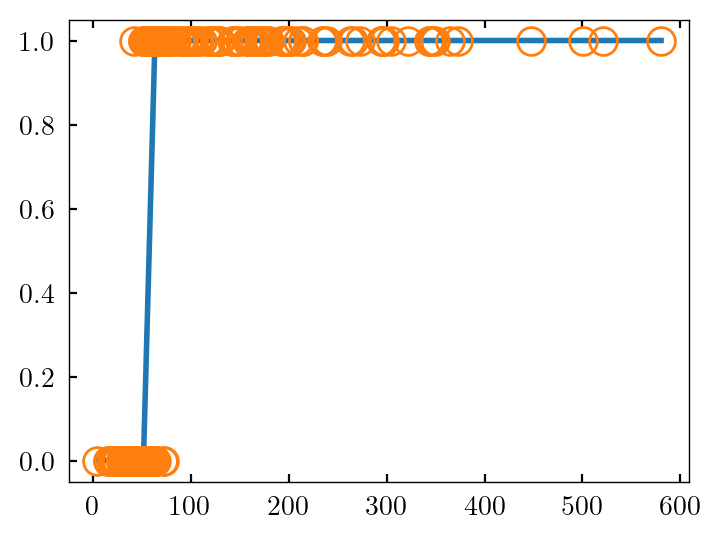

In [124]:
fig, ax = plt.subplots(figsize=(4, 3))
ylin = logreg.predict(xlin.reshape([len(xlin), 1]))
ax.plot(xlin, ylin)

# complete
ax.plot(X, y, 'o', mfc="None")

# complete
plt.show()

We can see that the logistic regression model is clearly superior to the linear regression model. The model is not perfect, but no model could be in the presence of noise. 

We also see that the probability cut ($p \approx 0.5 \;\mathrm{at\;mass} \approx 61.5$) is much closer to the true answer of 60. 

The previous example used a simple toy data set that was easy to visualize. But logistic regression can be extended to include multiple features, and more than two classes (in which case the problem is a multinomial one rather than a binomial one). 

This optimization happens entirely under the hood with `scikit-learn`.

**Problem 3f**

Fit a logistic regression model to the iris data set. 

Assess the accuracy of this model. 

*Hint* – [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) from `sklearn.metrics` will simplify your calculations.

In [127]:
from sklearn.metrics import accuracy_score

logreg = LogisticRegression()
logreg.fit(iris.data, iris.target)

# complete

/Users/jasonwu/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [129]:
model_pred = logreg.predict(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


/var/folders/j0/rqdpnvss1tlbffxb8bfzwnkw0000gn/T/ipykernel_70262/2528333013.py:7: UserWarning: You passed a edgecolor/edgecolors ('None') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(iris.data[:,0], iris.data[:,1],


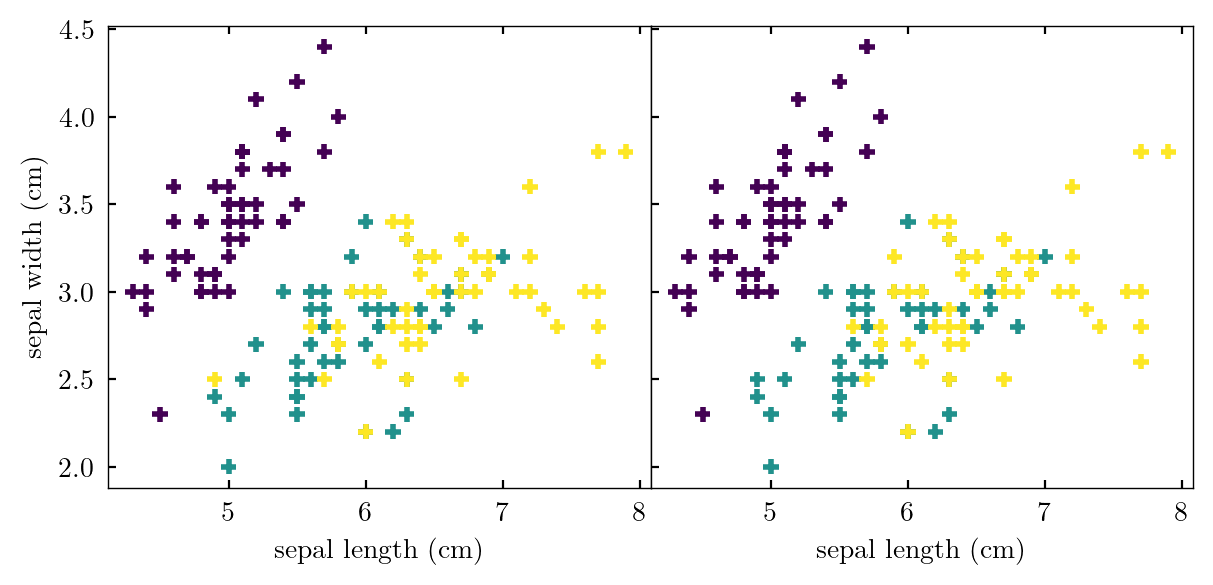

In [134]:
print(iris.feature_names)  # shows that sepal length is first feature and sepal width is second feature

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(7, 3))

for i, ax in enumerate([ax1, ax2]):
    # 0 actual, 1 predicted
    ax.scatter(iris.data[:,0], iris.data[:,1], 
               c = model_pred if i else iris.target, s = 30, 
               edgecolor = "None", cmap = "viridis")
    ax.set_xlabel('sepal length (cm)')
ax1.set_ylabel('sepal width (cm)')
ax2.set_yticklabels('')
plt.subplots_adjust(wspace=0)
plt.show()

In [ ]:
# complete
# complete
    
print('The accuracy of this model is {}' # complete

In conclustion, today we have learned the basics for the `scikit-learn` library. 

We have also learned how the logistic regression algorithm can be very useful for classification problems. Logistic regression is often used as a starting point when building machine learning models: when faced with a new data set, logistic regression can be applied with minimal tuning to get a sense of whether machine learning could be helpful in classifying the data. 

I also want to end with two caveats: 

1. Logistic regression is very powerful, but like all machine learning techniques, it also has limitations. For example, logistic regression can lead to "interpretable" results (such as the mean value where the curve transitions from 0 to 1), but these interpretations will not work if the features are correlated. 

2. The error rates (1 - accuracy) measured throughout this notebook are the "training error." This is not a particularly good way to measure the efficacy of a model as we will discuss in further detail later today. 

## Challenge Problem

Pick any classification model from the `scikit-learn` library and measure its accuracy when applied to the iris data set.